
# Dense-Only Evaluation with x‑CV Hyperparameter Selection (with RMSE / cRMSE‑z / aiRMSE)
**Comparison:** Raw‑PCA vs KRR→RKHS‑PCA (dense grid only)

This notebook performs **x‑direction cross‑validation (x‑CV)** to select hyperparameters for the proposed method
(KRR→RKHS‑PCA), then compares against Raw‑PCA on a dense grid.

**Metrics (dense grid) include:**
- **RMSE**（raw scale）
- **cRMSE‑z**（z標準化後の centered RMSE）
- **cRMSE**（rawスケール, 参考）
- **z‑RMSE**（両系列 z）
- **aiRMSE**（アフィン不変 RMSE）
- shape \(R^2\)（相関の2乗）, \(\mathrm{aiNRMSE}'\)（導関数の形一致）, ピーク位置誤差 \(|\Delta x_\*|\)
- RKHS 指標：中心化 RKHS 余弦，RKHS ai‑NRMSE


In [112]:

# =========================
# Configuration (edit here)
# =========================

# Experiment size
N_SUBJECTS   = 30
N_OBS_PER_SUBJECT = 50 #100のときはうまくいった
N_REPEATS    = 200

# Principal components to test
L_LIST = [1, 2, 3, 4, 5]

# Domain
X_MIN, X_MAX = -1.0, 1.0

# Dense evaluation grid
M_EVAL = 21

# Function generation
GENERATION_MODE = "gp"   # "rkhs" or "gp"
ELL_TRUE   = 0.30
SIGMA_A    = 1.0

# Observation noise (set via SNR)
SNR = 1.0

# ---------- x-CV hyperparameter selection ----------
# KERNEL_CANDIDATES = ["rbf", "matern32", "matern52"]
KERNEL_CANDIDATES = ["rbf"]
ELL_EXP_GRID = [-0.3, -0.1, 0.1, 0.3, 0.5]
LAMBDA_EXP_GRID = [-4, -3, -2, -1, 0]

# x-CV folds (contiguous blocks along x)
XCV_K_FOLDS = 5
# Objective for selection: "shape_R2", "zRMSE", "cRMSE_z", "cRMSE", or "RMSE"
XCV_OBJECTIVE = "zRMSE"

# Selection mode for lambda: "session_shared" (default) or "subject_specific"
LAMBDA_SELECTION_MODE = "session_shared"

# Numerical
JITTER = 1e-6
PROJ_REG = 1e-8   # dense->RKHS projection regularization

# Diagnostics
ENABLE_HEATMAP = False   # set True to plot a coarse heatmap around the selected (ell, lam) for the top kernel

# Randomness
RNG_SEED = 9999

# Demo switch
RUN_TINY_DEMO = False
TINY_DEMO_REPEATS = 5


In [113]:

import numpy as np
import math
import numpy.linalg as npl
import matplotlib.pyplot as plt

try:
    import pandas as pd
except Exception:
    pd = None

try:
    from ace_tools import display_dataframe_to_user
except Exception:
    display_dataframe_to_user = None

np.random.seed(RNG_SEED)


In [114]:

def k_rbf(x, y, ell):
    x = np.asarray(x).reshape(-1,1)
    y = np.asarray(y).reshape(1,-1)
    d2 = (x - y)**2
    return np.exp(-0.5 * d2 / (ell**2))

def k_matern32(x, y, ell):
    x = np.asarray(x).reshape(-1,1)
    y = np.asarray(y).reshape(1,-1)
    r = np.sqrt((x - y)**2)
    s = np.sqrt(3.0) * r / ell
    return (1.0 + s) * np.exp(-s)

def k_matern52(x, y, ell):
    x = np.asarray(x).reshape(-1,1)
    y = np.asarray(y).reshape(1,-1)
    r = np.sqrt((x - y)**2)
    s = np.sqrt(5.0) * r / ell
    return (1.0 + s + 5.0*(r**2)/(3.0*ell**2)) * np.exp(-s)

KERNELS = {"rbf": k_rbf, "matern32": k_matern32, "matern52": k_matern52}

def central_diff(y, x):
    y = np.asarray(y); x = np.asarray(x)
    N = len(y)
    dy = np.zeros_like(y, dtype=float)
    if N == 1:
        return dy
    if N == 2:
        h = x[1] - x[0]
        dy[0] = (y[1] - y[0]) / h
        dy[1] = dy[0]
        return dy
    for i in range(1, N-1):
        h1 = x[i] - x[i-1]
        h2 = x[i+1] - x[i]
        dy[i] = ( (y[i+1] - y[i]) / h2 * (2*h1/(h1+h2)) +
                  (y[i] - y[i-1]) / h1 * ( -2*h2/(h1+h2)) )
    dy[0]  = (y[1] - y[0]) / (x[1] - x[0])
    dy[-1] = (y[-1] - y[-2]) / (x[-1] - x[-2])
    return dy

def safe_corr(a, b):
    a = np.asarray(a).ravel(); b = np.asarray(b).ravel()
    sa = np.std(a); sb = np.std(b)
    if sa == 0 or sb == 0: return 0.0
    return float(np.corrcoef(a, b)[0,1])

def zscore(v):
    v = np.asarray(v); sd = np.std(v)
    if sd == 0: return v*0.0
    return (v - np.mean(v)) / sd

def rmse(a, b):
    a = np.asarray(a); b = np.asarray(b)
    return float(np.sqrt(np.mean((a-b)**2)))

def crmse(a, b):
    """Centered RMSE on raw scale: sqrt(RMSE^2 - bias^2)."""
    a = np.asarray(a); b = np.asarray(b)
    bias = float(np.mean(a) - np.mean(b))
    r = rmse(a, b)
    val2 = r*r - bias*bias
    return float(np.sqrt(val2) if val2 > 0 else 0.0)

def crmse_z(a, b):
    """Centered RMSE on z-scales (shape-level): apply zscore to both before cRMSE."""
    return crmse(zscore(a), zscore(b))

def airmse(a, b):
    """Affine-invariant RMSE: min_{alpha,beta} RMSE(alpha*b + beta, a)."""
    a = np.asarray(a); b = np.asarray(b)
    ba = b - np.mean(b); aa = a - np.mean(a)
    varb = float(np.dot(ba, ba) / len(b))
    cov  = float(np.dot(ba, aa) / len(b))
    alpha = 0.0 if varb == 0 else cov / varb
    beta  = float(np.mean(a) - alpha*np.mean(b))
    pred  = alpha*b + beta
    return rmse(a, pred)

def solve_spd(A, b):
    try:
        L = np.linalg.cholesky(A)
        y = np.linalg.solve(L, b)
        x = np.linalg.solve(L.T, y)
        return x
    except Exception:
        return np.linalg.solve(A, b)


In [115]:

def krr_fit_coeffs_general(x_train, s_train, x_basis, kernel_fn, ell, lam, jitter=1e-6):
    K_xb = kernel_fn(x_train, x_basis, ell)
    K_bb = kernel_fn(x_basis, x_basis, ell)
    if jitter > 0: K_bb = K_bb + jitter*np.eye(K_bb.shape[0])
    Ntr = len(x_train)
    M = K_xb.T @ K_xb + (Ntr * lam) * K_bb
    rhs = K_xb.T @ s_train
    return solve_spd(M, rhs)

def eval_from_coeffs_general(x_eval, x_basis, a, kernel_fn, ell):
    return kernel_fn(x_eval, x_basis, ell) @ a

def dual_pca_scores_and_loadings(X, L):
    T, p = X.shape
    G = X @ X.T
    vals, U = npl.eigh(G)
    idx = np.argsort(vals)[::-1]; vals = vals[idx]; U = U[:, idx]
    L_eff = min(L, np.sum(vals > 1e-12))
    valsL = vals[:L_eff]; UL = U[:, :L_eff]
    Z = UL * np.sqrt(valsL)
    inv_sqrt = np.diag(1.0 / np.sqrt(valsL)) if L_eff>0 else np.zeros((0,0))
    V = inv_sqrt @ UL.T @ X if L_eff>0 else np.zeros((0, p))
    return Z, V, valsL, UL

def reconstruct_from_dual_pca(X, L):
    col_mean = X.mean(axis=0, keepdims=True)
    Xc = X - col_mean
    Z, V, valsL, U = dual_pca_scores_and_loadings(Xc, L)
    X_L = Z @ V + col_mean
    return X_L, (Z, V, valsL, U, col_mean)

def rkhs_pca(A, K, L):
    T, Nb = A.shape
    W0 = A.mean(axis=0, keepdims=True)
    A_c = A - W0
    S = A_c @ K @ A_c.T
    vals, U = npl.eigh(S)
    idx = np.argsort(vals)[::-1]; vals = vals[idx]; U = U[:, idx]
    L_eff = min(L, np.sum(vals > 1e-12))
    nuL = vals[:L_eff]; UL = U[:, :L_eff]
    Z = UL * np.sqrt(nuL)
    inv_sqrt = np.diag(1.0 / np.sqrt(nuL)) if L_eff>0 else np.zeros((0,0))
    W = inv_sqrt @ UL.T @ A_c if L_eff>0 else np.zeros((0, Nb))
    A_L = Z @ W + W0
    return A_L, (Z, W, nuL, UL, W0)


In [116]:

def metrics_shape_grid(x, f_true, f_hat):
    """Return a rich set of shape metrics (dense grid)."""
    rho = safe_corr(f_true, f_hat)
    out = {
        "shape_R2": rho**2,
        "RMSE": rmse(f_true, f_hat),
        "cRMSE": crmse(f_true, f_hat),
        "cRMSE_z": crmse_z(f_true, f_hat),
        "zRMSE": rmse(zscore(f_true), zscore(f_hat)),
        "aiRMSE": airmse(f_true, f_hat),
    }
    df_true = central_diff(f_true, x)
    df_hat  = central_diff(f_hat,  x)
    rho_p = safe_corr(df_true, df_hat)
    out["aiNRMSE_prime"] = math.sqrt(max(0.0, 1.0 - rho_p**2))
    x_star_true = float(x[int(np.argmax(zscore(f_true)))])
    x_star_hat  = float(x[int(np.argmax(zscore(f_hat)))])
    out["dX_peak"] = abs(x_star_true - x_star_hat)
    return out

def dense_to_rkhs_coeffs(f_eval, K_eval_from_basis, K_basis, reg):
    M = K_eval_from_basis.T @ K_eval_from_basis + reg * K_basis
    rhs = K_eval_from_basis.T @ f_eval
    return solve_spd(M, rhs)

def rkhs_center_coeffs(a, K, w):
    num = float(a.T @ K @ w); den = float(w.T @ K @ w)
    if den <= 1e-15: return a.copy()
    return a - (num/den) * w

def rkhs_cosine_centered_from_dense(f_true_eval, f_hat_eval, K_eval_from_basis, K_basis, w_coeff, reg):
    a_true = dense_to_rkhs_coeffs(f_true_eval, K_eval_from_basis, K_basis, reg)
    a_hat  = dense_to_rkhs_coeffs(f_hat_eval,  K_eval_from_basis, K_basis, reg)
    ac = rkhs_center_coeffs(a_true, K_basis, w_coeff)
    bc = rkhs_center_coeffs(a_hat,  K_basis, w_coeff)
    num = float(ac.T @ K_basis @ bc)
    den = math.sqrt(float(ac.T @ K_basis @ ac)) * math.sqrt(float(bc.T @ K_basis @ bc))
    cosv = 0.0 if den <= 1e-15 else max(min(num/den, 1.0), -1.0)
    ai = math.sqrt(max(0.0, 1.0 - cosv**2))
    return dict(RKHS_cosine=cosv, RKHS_aiNRMSE=ai)


In [117]:

def subspace_similarity(U_true, U_est, L):
    U1 = U_true[:, :L]; U2 = U_est[:, :L]
    if U1.size == 0 or U2.size == 0:
        return dict(SubspaceSim=0.0, singvals=np.array([]))
    Q1, _ = np.linalg.qr(U1); Q2, _ = np.linalg.qr(U2)
    M = Q1.T @ Q2
    s = npl.svd(M, compute_uv=False)
    r = min(L, len(s))
    cos2_mean = float(np.mean(s[:r]**2)) if r > 0 else 0.0
    return dict(SubspaceSim=cos2_mean, singvals=s[:r])


In [118]:

def make_block_folds(N, K):
    sizes = [N//K + (1 if i < (N % K) else 0) for i in range(K)]
    idx = np.arange(N); folds = []
    start = 0
    for s in sizes:
        te = idx[start:start+s]; folds.append(te); start += s
    return folds

def xcv_score_session(x_obs, Y_obs, kernel_name, ell, lam, K=2, jitter=1e-6, objective="shape_R2"):
    kernel_fn = KERNELS[kernel_name]
    folds = make_block_folds(len(x_obs), K)
    scores = []
    for t in range(Y_obs.shape[0]):
        y = Y_obs[t]
        for te in folds:
            tr = np.setdiff1d(np.arange(len(x_obs)), te)
            mu_tr = float(np.mean(y[tr])); sd_tr = float(np.std(y[tr])) or 1.0
            s_tr = (y[tr] - mu_tr) / sd_tr
            a_hat = krr_fit_coeffs_general(x_obs[tr], s_tr, x_obs, kernel_fn, ell, lam, jitter)
            s_pred_te = eval_from_coeffs_general(x_obs[te], x_obs, a_hat, kernel_fn, ell)
            y_pred_te = mu_tr + sd_tr * s_pred_te
            y_te = y[te]
            if objective == "shape_R2":
                r = safe_corr(zscore(y_te), zscore(y_pred_te)); scores.append(r*r)
            elif objective == "zRMSE":
                scores.append(-rmse(zscore(y_te), zscore(y_pred_te)))
            elif objective == "cRMSE":
                scores.append(-crmse(y_te, y_pred_te))
            elif objective == "cRMSE_z":
                scores.append(-crmse_z(y_te, y_pred_te))
            elif objective == "RMSE":
                scores.append(-rmse(y_te, y_pred_te))
            else:
                r = safe_corr(zscore(y_te), zscore(y_pred_te)); scores.append(r*r)
    return float(np.mean(scores)) if len(scores) > 0 else -np.inf

def xcv_select_session_params(x_obs, Y_obs, kernel_candidates, ell_exp_grid, lam_exp_grid,
                              K=2, jitter=1e-6, objective="shape_R2"):
    dx = np.diff(np.sort(x_obs)).mean() if len(x_obs) > 1 else 1.0
    ell_grid = (dx * (10.0 ** np.array(ell_exp_grid))).tolist()
    lam_grid = (10.0 ** np.array(lam_exp_grid)).tolist()
    best = {"score": -np.inf}
    for kname in kernel_candidates:
        for ell in ell_grid:
            for lam in lam_grid:
                sc = xcv_score_session(x_obs, Y_obs, kname, ell, lam, K, jitter, objective)
                if sc > best["score"]:
                    best = {"score": sc, "kernel": kname, "ell": float(ell), "lam": float(lam)}
    return best

def xcv_select_lambda_per_subject(x_obs, y_obs, kernel_name, ell, lam_exp_grid, K=2, jitter=1e-6, objective="shape_R2"):
    lam_grid = (10.0 ** np.array(lam_exp_grid)).tolist()
    best = {"score": -np.inf, "lam": None}
    for lam in lam_grid:
        folds = make_block_folds(len(x_obs), K)
        scores = []
        for te in folds:
            tr = np.setdiff1d(np.arange(len(x_obs)), te)
            mu_tr = float(np.mean(y_obs[tr])); sd_tr = float(np.std(y_obs[tr])) or 1.0
            s_tr = (y_obs[tr] - mu_tr) / sd_tr
            a_hat = krr_fit_coeffs_general(x_obs[tr], s_tr, x_obs, KERNELS[kernel_name], ell, lam, jitter)
            s_pred_te = eval_from_coeffs_general(x_obs[te], x_obs, a_hat, KERNELS[kernel_name], ell)
            y_pred_te = mu_tr + sd_tr * s_pred_te
            if objective == "shape_R2":
                r = safe_corr(zscore(y_obs[te]), zscore(y_pred_te)); scores.append(r*r)
            elif objective == "zRMSE":
                scores.append(-rmse(zscore(y_obs[te]), zscore(y_pred_te)))
            elif objective == "cRMSE":
                scores.append(-crmse(y_obs[te], y_pred_te))
            elif objective == "cRMSE_z":
                scores.append(-crmse_z(y_obs[te], y_pred_te))
            elif objective == "RMSE":
                scores.append(-rmse(y_obs[te], y_pred_te))
            else:
                r = safe_corr(zscore(y_obs[te]), zscore(y_pred_te)); scores.append(r*r)
        sc = float(np.mean(scores)) if len(scores)>0 else -np.inf
        if sc > best["score"]:
            best = {"score": sc, "lam": float(lam)}
    return best


In [119]:

def simulate_one_replication_with_selection(x_obs, x_eval,
                                            generation_mode, ell_true, sigma_a, snr,
                                            kernel_candidates, ell_exp_grid, lam_exp_grid,
                                            xcv_K, xcv_objective, lambda_mode,
                                            jitter, proj_reg,
                                            n_subjects, L_list):
    T = n_subjects; N = len(x_obs); M = len(x_eval)

    # ----- Generate true functions -----
    F_true_obs = np.zeros((T, N)); F_true_eval = np.zeros((T, M))
    if generation_mode == "rkhs":
        K_gen_obs  = k_rbf(x_obs,  x_obs,  ell_true)
        K_gen_eval = k_rbf(x_eval, x_obs,  ell_true)
        for t in range(T):
            a = np.random.normal(0.0, sigma_a, size=N)
            F_true_obs[t]  = K_gen_obs  @ a
            F_true_eval[t] = K_gen_eval @ a
    elif generation_mode == "gp":
        x_joint = np.concatenate([x_obs, x_eval])
        K_joint = k_rbf(x_joint, x_joint, ell_true) + 1e-10*np.eye(len(x_joint))
        Lc = np.linalg.cholesky(K_joint)
        for t in range(T):
            z = np.random.normal(size=len(x_joint))
            f_joint = Lc @ z
            F_true_obs[t]  = f_joint[:N]
            F_true_eval[t] = f_joint[N:]
    else:
        raise ValueError("Unknown generation mode")

    # ----- Observations with noise -----
    Y_obs = np.zeros((T, N))
    for t in range(T):
        f = F_true_obs[t]
        sig = np.std(f); noise_std = sig / max(snr, 1e-12)
        Y_obs[t] = f + np.random.normal(0.0, noise_std, size=N)

    # ----- x-CV selection (session-level) -----
    best = xcv_select_session_params(x_obs, Y_obs, kernel_candidates, ell_exp_grid, lam_exp_grid,
                                     K=xcv_K, jitter=jitter, objective=xcv_objective)
    selected_kernel = best["kernel"]; selected_ell = best["ell"]; selected_lam = best["lam"]
    xcv_score_selected = xcv_score_session(x_obs, Y_obs, selected_kernel, selected_ell, selected_lam,
                                           K=xcv_K, jitter=jitter, objective=xcv_objective)

    # Subject-specific lambda (optional)
    lam_per_subject = np.full(T, selected_lam, dtype=float)
    if lambda_mode == "subject_specific":
        for t in range(T):
            res = xcv_select_lambda_per_subject(x_obs, Y_obs[t], selected_kernel, selected_ell,
                                                ell_exp_grid, K=xcv_K, jitter=jitter, objective=xcv_objective)
            lam_per_subject[t] = res["lam"] if res["lam"] is not None else selected_lam

    # ----- Build RKHS metric with selected (kernel, ell) -----
    kernel_fn = KERNELS[selected_kernel]
    K_basis = kernel_fn(x_obs, x_obs, selected_ell) + jitter*np.eye(N)
    w_coeff = np.ones(N) / N
    K_eval_from_basis = kernel_fn(x_eval, x_obs, selected_ell)

    # ----- Standardize observations for final fit -----
    Y_std = np.zeros_like(Y_obs)
    for t in range(T):
        Y_std[t] = zscore(Y_obs[t])

    # ----- Fit KRR coeffs per subject -----
    A_hat = np.zeros((T, N))
    for t in range(T):
        A_hat[t] = krr_fit_coeffs_general(x_obs, Y_std[t], x_obs, kernel_fn, selected_ell, lam_per_subject[t], jitter)

    # ----- PCA pipelines -----
    X_L_dict = {}; U_raw_dict = {}
    for L in L_list:
        X_L, (Zr, Vr, valsLr, Ur, col_mean) = reconstruct_from_dual_pca(Y_std, L)
        X_L_dict[L] = X_L; U_raw_dict[L] = Ur

    A_L_dict = {}; U_rkhs_dict = {}
    for L in L_list:
        A_L, (Zk, Wk, nuLk, Uk, W0) = rkhs_pca(A_hat, K_basis, L)
        A_L_dict[L] = A_L; U_rkhs_dict[L] = Uk

    # ----- True subspace (noise-free, RKHS metric) -----
    A_true = np.zeros((T, N))
    for t in range(T):
        A_true[t] = dense_to_rkhs_coeffs(F_true_eval[t], K_eval_from_basis, K_basis, proj_reg)
    A_true_c = A_true - A_true.mean(axis=0, keepdims=True)
    S_true = A_true_c @ K_basis @ A_true_c.T
    vals_true, U_true = npl.eigh(S_true)
    idx = np.argsort(vals_true)[::-1]; U_true = U_true[:, idx]

    # ----- Per-L metrics on dense grid -----
    results = []
    for L in L_list:
        Xhat_raw_obs = X_L_dict[L]
        Xhat_raw_eval = np.vstack([np.interp(x_eval, x_obs, Xhat_raw_obs[t]) for t in range(T)])
        Ahat_L = A_L_dict[L]
        Xhat_rkhs_eval = (Ahat_L @ K_eval_from_basis.T)

        m_shape_raw, m_shape_rkhs = [], []
        m_rh_raw, m_rh_rkhs = [], []

        for t in range(T):
            f_true_eval = F_true_eval[t]
            f_raw_eval  = Xhat_raw_eval[t]
            f_krr_eval  = Xhat_rkhs_eval[t]

            g1 = metrics_shape_grid(x_eval, f_true_eval, f_raw_eval)
            g2 = metrics_shape_grid(x_eval, f_true_eval, f_krr_eval)
            m_shape_raw.append(g1); m_shape_rkhs.append(g2)

            r1 = rkhs_cosine_centered_from_dense(f_true_eval, f_raw_eval, K_eval_from_basis, K_basis, w_coeff, proj_reg)
            r2 = rkhs_cosine_centered_from_dense(f_true_eval, f_krr_eval, K_eval_from_basis, K_basis, w_coeff, proj_reg)
            m_rh_raw.append(r1); m_rh_rkhs.append(r2)

        def agg(list_of_dicts, prefix):
            out = {}
            for k in list_of_dicts[0].keys():
                vals = [d[k] for d in list_of_dicts]
                out[f"{prefix}_{k}_mean"] = float(np.mean(vals))
                out[f"{prefix}_{k}_std"]  = float(np.std(vals, ddof=1))
            return out

        agg_raw  = agg(m_shape_raw,  "Raw")
        agg_rkhs = agg(m_shape_rkhs, "RKHS")
        agg_raw_rh  = agg(m_rh_raw,  "RawRKHS")
        agg_rkhs_rh = agg(m_rh_rkhs, "RKHSRKHS")

        ss_raw  = subspace_similarity(U_true, U_raw_dict[L],  L)
        ss_rkhs = subspace_similarity(U_true, U_rkhs_dict[L], L)

        row = dict(L=L, kernel=selected_kernel, ell=selected_ell,
                   lam_session=selected_lam, lam_mode=lambda_mode,
                   xcv_score_selected=xcv_score_selected, xcv_objective=xcv_objective)
        row.update(agg_raw); row.update(agg_rkhs)
        row.update(agg_raw_rh); row.update(agg_rkhs_rh)
        row["SubspaceSim_Raw"]  = ss_raw["SubspaceSim"]
        row["SubspaceSim_RKHS"] = ss_rkhs["SubspaceSim"]
        results.append(row)

    return results, dict(kernel=selected_kernel, ell=selected_ell,
                         lam_session=selected_lam, lam_mode=lambda_mode,
                         xcv_score_selected=xcv_score_selected,
                         xcv_objective=xcv_objective)


In [120]:

def run_simulation_with_selection(n_subjects=N_SUBJECTS,
                                  n_obs=N_OBS_PER_SUBJECT,
                                  n_repeats=N_REPEATS,
                                  L_list=L_LIST,
                                  generation_mode=GENERATION_MODE,
                                  ell_true=ELL_TRUE,
                                  sigma_a=SIGMA_A,
                                  snr=SNR,
                                  kernel_candidates=KERNEL_CANDIDATES,
                                  ell_exp_grid=ELL_EXP_GRID,
                                  lam_exp_grid=LAMBDA_EXP_GRID,
                                  xcv_K=XCV_K_FOLDS,
                                  xcv_objective=XCV_OBJECTIVE,
                                  lambda_mode=LAMBDA_SELECTION_MODE,
                                  jitter=JITTER,
                                  proj_reg=PROJ_REG,
                                  rng_seed=RNG_SEED):
    np.random.seed(rng_seed)

    x_obs  = np.linspace(X_MIN, X_MAX, n_obs)
    x_eval = np.linspace(X_MIN, X_MAX, M_EVAL)

    all_rows = []; hyper_rows = []

    for r in range(n_repeats):
        rows, hinfo = simulate_one_replication_with_selection(
            x_obs, x_eval,
            generation_mode, ell_true, sigma_a, snr,
            kernel_candidates, ell_exp_grid, lam_exp_grid,
            xcv_K, xcv_objective, lambda_mode,
            jitter, proj_reg,
            n_subjects, L_list
        )
        for row in rows:
            row2 = dict(rep=r, **row)
            all_rows.append(row2)
        hyper_rows.append(dict(rep=r, **hinfo))

    df = pd.DataFrame(all_rows) if pd is not None else None
    dfh = pd.DataFrame(hyper_rows) if pd is not None else None
    return all_rows, df, dfh

def summarize_metric_by_L(df, col):
    g = df.groupby("L")[col].agg(['mean', 'std', 'count']).reset_index()
    g = g.rename(columns={'mean':'mean','std':'std','count':'n'})
    g['std'] = g['std'].fillna(0.0)
    se = g['std'] / np.sqrt(np.maximum(g['n'], 1))
    g['ci_low']  = g['mean'] - 1.96*se
    g['ci_high'] = g['mean'] + 1.96*se
    return g

def plot_metric_pair_with_ci(df, raw_col, rkhs_col, ylabel, title, raw_label="Raw-PCA", rkhs_label="KRR→RKHS-PCA"):
    s_raw  = summarize_metric_by_L(df, raw_col)
    s_rkhs = summarize_metric_by_L(df, rkhs_col)
    plt.figure()
    plt.errorbar(s_raw['L'], s_raw['mean'],  yerr=np.vstack([s_raw['mean']-s_raw['ci_low'], s_raw['ci_high']-s_raw['mean']]),  marker="o", label=raw_label)
    plt.errorbar(s_rkhs['L'], s_rkhs['mean'],yerr=np.vstack([s_rkhs['mean']-s_rkhs['ci_low'], s_rkhs['ci_high']-s_rkhs['mean']]),marker="o", label=rkhs_label)
    plt.xlabel("Number of PCs (L)"); plt.ylabel(ylabel); plt.title(title + " (dense, x‑CV)"); plt.legend(); plt.show()


In [121]:

# ==============
# Tiny demo run
# ==============
if RUN_TINY_DEMO:
    rows, df, dfh = run_simulation_with_selection(n_subjects=N_SUBJECTS,
                                                  n_obs=N_OBS_PER_SUBJECT,
                                                  n_repeats=TINY_DEMO_REPEATS,
                                                  L_list=L_LIST,
                                                  generation_mode=GENERATION_MODE,
                                                  ell_true=ELL_TRUE,
                                                  sigma_a=SIGMA_A,
                                                  snr=SNR,
                                                  kernel_candidates=KERNEL_CANDIDATES,
                                                  ell_exp_grid=ELL_EXP_GRID,
                                                  lam_exp_grid=LAMBDA_EXP_GRID,
                                                  xcv_K=XCV_K_FOLDS,
                                                  xcv_objective=XCV_OBJECTIVE,
                                                  lambda_mode=LAMBDA_SELECTION_MODE,
                                                  jitter=JITTER,
                                                  proj_reg=PROJ_REG,
                                                  rng_seed=RNG_SEED)

    if pd is not None:
        display_df = df.groupby("L").agg({
            "Raw_shape_R2_mean":"mean",
            "RKHS_shape_R2_mean":"mean",
            "Raw_RMSE_mean":"mean",
            "RKHS_RMSE_mean":"mean",
            "Raw_cRMSE_z_mean":"mean",
            "RKHS_cRMSE_z_mean":"mean",
            "Raw_cRMSE_mean":"mean",
            "RKHS_cRMSE_mean":"mean",
            "Raw_zRMSE_mean":"mean",
            "RKHS_zRMSE_mean":"mean",
            "Raw_aiRMSE_mean":"mean",
            "RKHS_aiRMSE_mean":"mean",
            "Raw_aiNRMSE_prime_mean":"mean",
            "RKHS_aiNRMSE_prime_mean":"mean",
            "Raw_dX_peak_mean":"mean",
            "RKHS_dX_peak_mean":"mean",
            "RawRKHS_RKHS_cosine_mean":"mean",
            "RKHSRKHS_RKHS_cosine_mean":"mean",
            "RawRKHS_RKHS_aiNRMSE_mean":"mean",
            "RKHSRKHS_RKHS_aiNRMSE_mean":"mean",
            "SubspaceSim_Raw":"mean",
            "SubspaceSim_RKHS":"mean"
        }).reset_index()

        # Robust cv_diag: select only available columns, and add XCV_OBJECTIVE if needed
        if dfh is not None:
            want = ["rep","kernel","ell","lam_session","lam_mode","xcv_objective","xcv_score_selected"]
            have = [c for c in want if c in dfh.columns]
            cv_diag = dfh[have].copy()
            if "xcv_objective" not in cv_diag.columns:
                cv_diag["xcv_objective"] = XCV_OBJECTIVE
        else:
            cv_diag = None

        if display_dataframe_to_user is not None:
            display_dataframe_to_user("Tiny demo: metric overview (dense, x‑CV, +RMSE)", display_df)
            if cv_diag is not None:
                display_dataframe_to_user("Tiny demo: selected hyperparameters & x‑CV score", cv_diag)
        else:
            print(display_df)
            if cv_diag is not None:
                print(cv_diag)

        # Plots — include RMSE
        plot_metric_pair_with_ci(df, "Raw_shape_R2_mean", "RKHS_shape_R2_mean",
                                 ylabel="Shape $R^2$ (dense)", title="Shape $R^2$ vs L")
        plot_metric_pair_with_ci(df, "Raw_RMSE_mean", "RKHS_RMSE_mean",
                                 ylabel="RMSE (dense)", title="RMSE vs L")
        plot_metric_pair_with_ci(df, "Raw_cRMSE_z_mean", "RKHS_cRMSE_z_mean",
                                 ylabel="cRMSE‑z (dense)", title="cRMSE‑z vs L")
        plot_metric_pair_with_ci(df, "Raw_zRMSE_mean", "RKHS_zRMSE_mean",
                                 ylabel="z‑RMSE (dense)", title="z‑RMSE vs L")
        plot_metric_pair_with_ci(df, "Raw_aiRMSE_mean", "RKHS_aiRMSE_mean",
                                 ylabel="aiRMSE (dense)", title="aiRMSE vs L")
        plot_metric_pair_with_ci(df, "Raw_aiNRMSE_prime_mean", "RKHS_aiNRMSE_prime_mean",
                                 ylabel="aiNRMSE' (slope agreement)", title="Derivative agreement vs L")
        plot_metric_pair_with_ci(df, "Raw_dX_peak_mean", "RKHS_dX_peak_mean",
                                 ylabel="Peak location error |Δx*|", title="Peak localization vs L")
        plot_metric_pair_with_ci(df, "RawRKHS_RKHS_cosine_mean", "RKHSRKHS_RKHS_cosine_mean",
                                 ylabel="Centered RKHS cosine", title="Centered RKHS cosine vs L")
    else:
        print("Install pandas to view tables and plots.")



## Full run (200×) — execute the next cell
This will select \((\text{kernel},\ell,\lambda)\) by x‑CV (session‑level or subject‑specific \(\lambda\) if enabled),
then compare Raw‑PCA vs KRR→RKHS‑PCA on the dense grid, and **plot shape‑level metrics** (including **RMSE**) with 95% CIs.


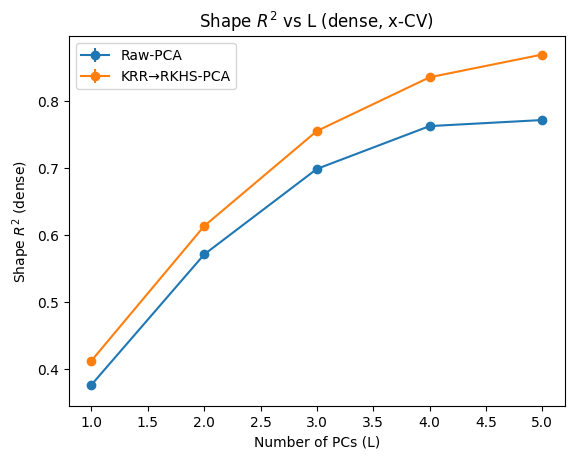

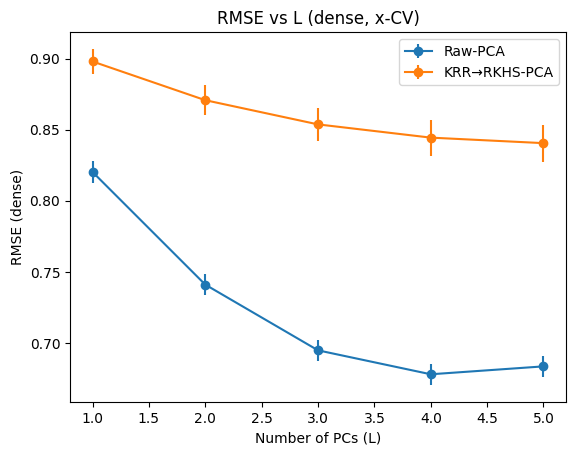

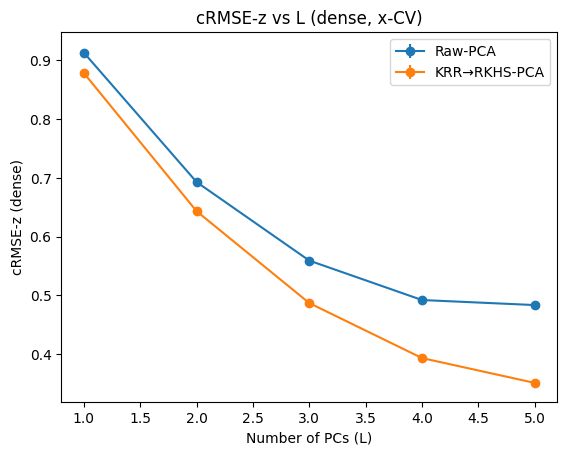

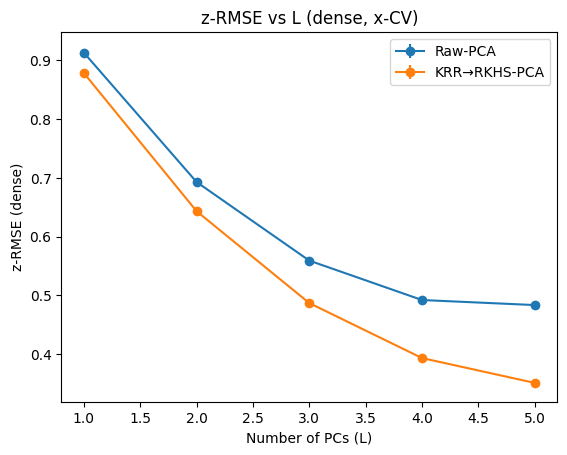

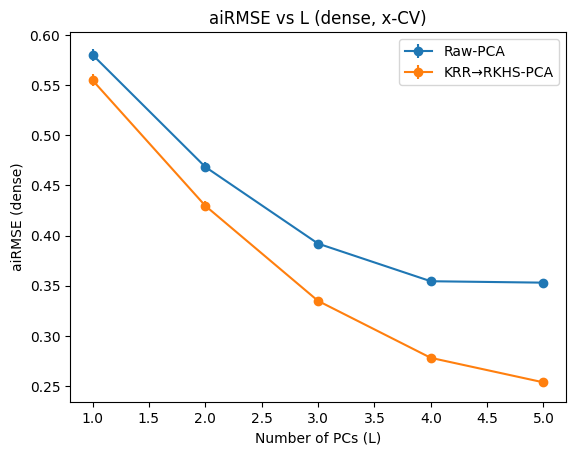

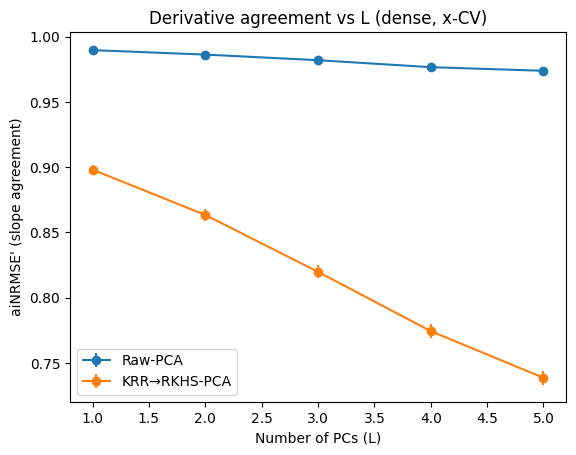

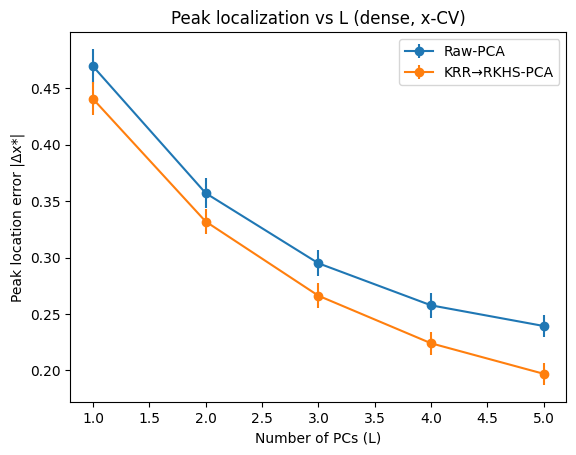

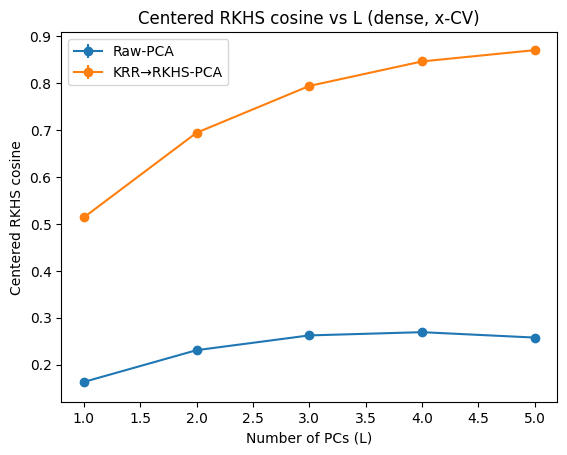

In [122]:

# Uncomment to perform the full run with the current Config (N_REPEATS)
rows, df, dfh = run_simulation_with_selection()
if pd is not None:
    if display_dataframe_to_user is not None:
        want = ["rep","kernel","ell","lam_session","lam_mode","xcv_objective","xcv_score_selected"]
        have = [c for c in want if c in dfh.columns]
        display_dataframe_to_user("Selected hyperparameters & x‑CV score (dense, x‑CV)", dfh[have])
    plot_metric_pair_with_ci(df, "Raw_shape_R2_mean", "RKHS_shape_R2_mean",
                             ylabel="Shape $R^2$ (dense)", title="Shape $R^2$ vs L")
    plot_metric_pair_with_ci(df, "Raw_RMSE_mean", "RKHS_RMSE_mean",
                             ylabel="RMSE (dense)", title="RMSE vs L")
    plot_metric_pair_with_ci(df, "Raw_cRMSE_z_mean", "RKHS_cRMSE_z_mean",
                             ylabel="cRMSE‑z (dense)", title="cRMSE‑z vs L")
    plot_metric_pair_with_ci(df, "Raw_zRMSE_mean", "RKHS_zRMSE_mean",
                             ylabel="z‑RMSE (dense)", title="z‑RMSE vs L")
    plot_metric_pair_with_ci(df, "Raw_aiRMSE_mean", "RKHS_aiRMSE_mean",
                             ylabel="aiRMSE (dense)", title="aiRMSE vs L")
    plot_metric_pair_with_ci(df, "Raw_aiNRMSE_prime_mean", "RKHS_aiNRMSE_prime_mean",
                             ylabel="aiNRMSE' (slope agreement)", title="Derivative agreement vs L")
    plot_metric_pair_with_ci(df, "Raw_dX_peak_mean", "RKHS_dX_peak_mean",
                             ylabel="Peak location error |Δx*|", title="Peak localization vs L")
    plot_metric_pair_with_ci(df, "RawRKHS_RKHS_cosine_mean", "RKHSRKHS_RKHS_cosine_mean",
                             ylabel="Centered RKHS cosine", title="Centered RKHS cosine vs L")
